# Projeto de Doenças Cardiovasculares - Regressão Logística


Nessa tarefa irei construir um modelo que nos ajude a prever doenças cardiovasculares, a base contém dados reais.

age - idade dos pacientes

gender - genero (2 mulheres) (1 homens)

height - altura dos pacientes

weight - peso dos pacientes

gluc - glicose

smoke - fumante (1) não fumante (0)

alco - consume alcool (1) não consome (0)

active - realiza atividades fisicas (1) não realiza (0)

cardio_disease - tem doença cardio (1) não tem (0) - Variável target


In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, classification_report, precision_score, recall_score

# 1) Carregando e tratando a base de dados.


In [36]:
# 1) Carregar base
df = pd.read_csv("CARDIO_BASE.csv", sep=";")

# 2) Visão inicial
display(df.head())
print("Shape:", df.shape)

# 3) Tipos e "saúde" das colunas
print("\nDtypes:")
print(df.dtypes)

print("\nInfo:")
df.info()

# 4) Tratamento de tipo: weight (object -> float)
df["weight"] = (
    df["weight"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df["weight"] = pd.to_numeric(df["weight"], errors="coerce")

print("\nDtypes após conversão do weight:")
print(df.dtypes)

# 5) Dados faltantes
print("\nValores faltantes por coluna:")
print(df.isna().sum())

if df["weight"].isna().sum() > 0:
    df["weight"] = df["weight"].fillna(df["weight"].median())

# 6) Duplicados
dup_count = df.duplicated().sum()
print("\nLinhas duplicadas (exatas):", dup_count)

# Remover duplicados
df = df.drop_duplicates().reset_index(drop=True)
print("Shape após remover duplicados:", df.shape)

# 7) Outliers / valores implausíveis
# Regras robustas e bem comuns em dados antropométricos:

out_height = (~df["height"].between(120, 220)).sum()
out_weight = (~df["weight"].between(35, 180)).sum()
out_age    = (~df["age"].between(18, 100)).sum()

print("\nContagem de possíveis outliers (regras plausíveis):")
print("height fora de 120–220:", out_height)
print("weight fora de 35–180:", out_weight)
print("age fora de 18–100:", out_age)

# Remoção para não distorcer scaler/modelo
mask = (
    df["height"].between(120, 220) &
    df["weight"].between(35, 180) &
    df["age"].between(18, 100)
)

df = df.loc[mask].reset_index(drop=True)
print("\nShape após remoção de outliers:", df.shape)

# 8) (Opcional) Resumo estatístico pós-tratamento
display(df.describe(include="all").T)

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
0,50,2,168,62,1,1,0,0,1,0
1,55,1,156,85,3,1,0,0,1,1
2,52,1,165,64,3,1,0,0,0,1
3,48,2,169,82,1,1,0,0,1,1
4,48,1,156,56,1,1,0,0,0,0


Shape: (10000, 10)

Dtypes:
age                int64
gender             int64
height             int64
weight            object
cholesterol        int64
gluc               int64
smoke              int64
alco               int64
active             int64
cardio_disease     int64
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             10000 non-null  int64 
 1   gender          10000 non-null  int64 
 2   height          10000 non-null  int64 
 3   weight          10000 non-null  object
 4   cholesterol     10000 non-null  int64 
 5   gluc            10000 non-null  int64 
 6   smoke           10000 non-null  int64 
 7   alco            10000 non-null  int64 
 8   active          10000 non-null  int64 
 9   cardio_disease  10000 non-null  int64 
dtypes: int64(9), object(1)
memory usage: 781.4+ KB

Dtypes após 

,count,mean,std,min,25%,50%,75%,max
age,9631.0,53.301422,6.815671,30.0,48.0,54.0,58.0,65.0
gender,9631.0,1.351885,0.477583,1.0,1.0,1.0,2.0,2.0
height,9631.0,164.355207,8.025581,120.0,159.0,165.0,170.0,198.0
weight,9631.0,74.526851,14.618486,37.0,65.0,72.0,82.0,180.0
cholesterol,9631.0,1.376804,0.685071,1.0,1.0,1.0,2.0,3.0
gluc,9631.0,1.229260,0.572636,1.0,1.0,1.0,1.0,3.0
smoke,9631.0,0.091995,0.289033,0.0,0.0,0.0,0.0,1.0
alco,9631.0,0.055757,0.229465,0.0,0.0,0.0,0.0,1.0
active,9631.0,0.792441,0.405580,0.0,1.0,1.0,1.0,1.0
cardio_disease,9631.0,0.508358,0.499956,0.0,0.0,1.0,1.0,1.0


# 2) Exploração dos dados com uma análise bem completa, plotando 3 gráficos.



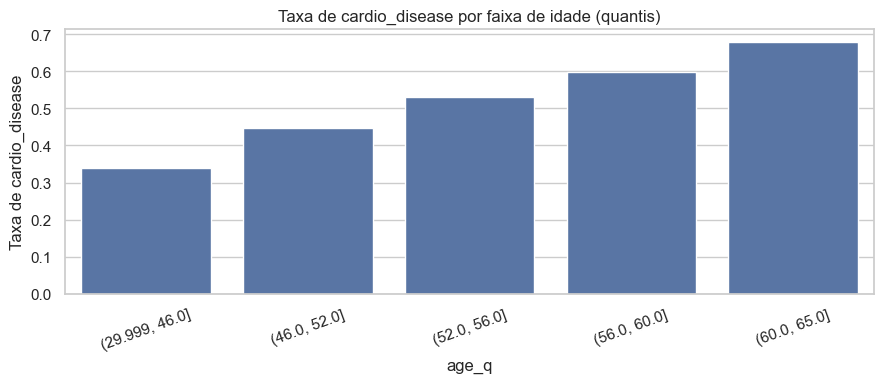

,age_q,taxa_cardio
0,"(29.999, 46.0]",0.339388
1,"(46.0, 52.0]",0.447495
2,"(52.0, 56.0]",0.531389
3,"(56.0, 60.0]",0.597954
4,"(60.0, 65.0]",0.678546


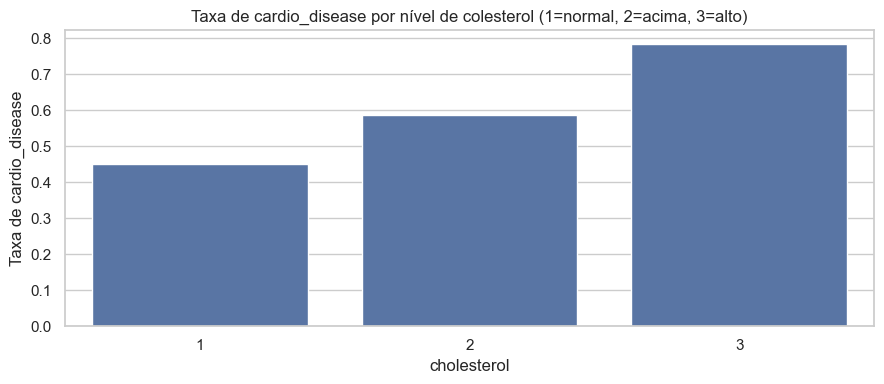

,cholesterol,taxa_cardio
0,1,0.450007
1,2,0.586433
2,3,0.782108


,cholesterol,qtd
0,1,7131
1,2,1371
2,3,1129


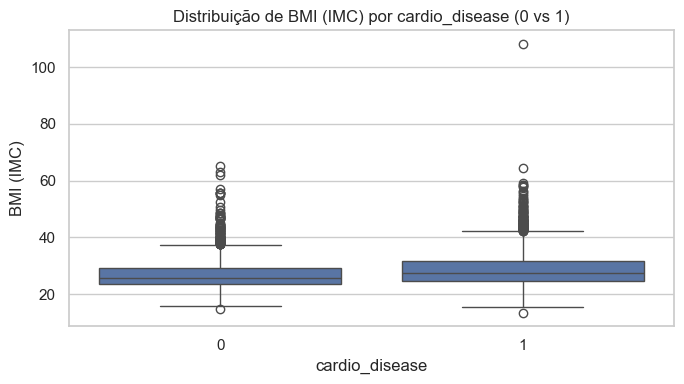

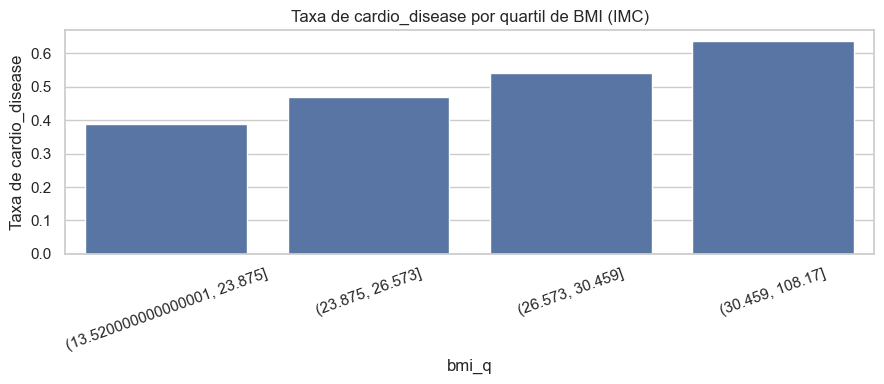

,bmi_q,taxa_cardio
0,"(13.520000000000001, 23.875]",0.389803
1,"(23.875, 26.573]",0.469269
2,"(26.573, 30.459]",0.539656
3,"(30.459, 108.17]",0.636213


In [37]:
#EDA - Análise bivariada

sns.set_theme(style="whitegrid", context="notebook")

def add_bmi(data: pd.DataFrame, weight_col: str = "weight", height_col: str = "height") -> pd.DataFrame:
    """Cria BMI (IMC) = peso/(altura_m^2). Retorna cópia."""
    out = data.copy()
    out["bmi"] = out[weight_col] / ((out[height_col] / 100) ** 2)
    return out


def add_quantile_bins(data: pd.DataFrame, col: str, q: int, new_col: str) -> pd.DataFrame:
    """Cria bins por quantis com qcut. Retorna cópia."""
    out = data.copy()
    out[new_col] = pd.qcut(out[col], q=q)
    return out


def target_rate_table(data: pd.DataFrame, group_col: str, target_col: str = "cardio_disease") -> pd.DataFrame:
    """Tabela de taxa do target por grupo (sem FutureWarning)."""
    return (
        data.groupby(group_col, observed=True)[target_col]
            .mean()
            .rename("taxa_cardio")
            .reset_index()
            .sort_values("taxa_cardio")
    )


def plot_target_rate_bar(data: pd.DataFrame, x: str, y: str = "cardio_disease", title: str = "", rotate_xticks: int = 0):
    """Barplot da taxa média do target por categoria."""
    plt.figure(figsize=(9, 4))
    ax = sns.barplot(data=data, x=x, y=y, estimator=np.mean, errorbar=None)
    ax.set_title(title)
    ax.set_xlabel(x)
    ax.set_ylabel("Taxa de cardio_disease")
    if rotate_xticks:
        plt.xticks(rotation=rotate_xticks)
    plt.tight_layout()
    plt.show()

# Alterar weight para INT
df = df.copy()
df["weight"] = pd.to_numeric(
    df["weight"].astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
)
df["weight"] = df["weight"].fillna(df["weight"].median())

# Criar features auxiliares para análise
df = add_bmi(df)
df = add_quantile_bins(df, col="age", q=5, new_col="age_q")  
df = add_quantile_bins(df, col="bmi", q=4, new_col="bmi_q")

# GRÁFICO 1: IDADE por DOENÇA CARDIOVASCULAR
plot_target_rate_bar(
    data=df,
    x="age_q",
    title="Taxa de cardio_disease por faixa de idade (quantis)",
    rotate_xticks=20
)

age_rates = target_rate_table(df, "age_q")
display(age_rates)

# COLESTEROL vc DOENCA CARDIOVASCULAR
plot_target_rate_bar(
    data=df,
    x="cholesterol",
    title="Taxa de cardio_disease por nível de colesterol (1=normal, 2=acima, 3=alto)"
)

chol_rates = target_rate_table(df, "cholesterol")
display(chol_rates)

chol_counts = df["cholesterol"].value_counts().rename_axis("cholesterol").reset_index(name="qtd")
display(chol_counts)

# GRAFICO 3) IMC por DOENCA CARDIOVASCULAR
# 3a) Distribuição do BMI por classe (boxplot)
plt.figure(figsize=(7, 4))
ax = sns.boxplot(data=df, x="cardio_disease", y="bmi")
ax.set_title("Distribuição de BMI (IMC) por cardio_disease (0 vs 1)")
ax.set_xlabel("cardio_disease")
ax.set_ylabel("BMI (IMC)")
plt.tight_layout()
plt.show()

# 3b) Taxa por quartis de BMI
plot_target_rate_bar(
    data=df,
    x="bmi_q",
    title="Taxa de cardio_disease por quartil de BMI (IMC)",
    rotate_xticks=20
)

bmi_rates = target_rate_table(df, "bmi_q")
display(bmi_rates)

# INSIGHTS #

* Podemos notar que com o aumento da idade, a taxa de doença cardiovascular fica maior
* Quanto mais alto o nível de colesterol, mesmo em pessoas mais jovens, maior o risco de doença cardiovascular.
* Quanto maior o IMC (BMI), maior o risco de doenças.

# 3) Nessa etapa você deve trazer a matriz de correlação e apontar insights acerca das variáveis com um relacionamento mais forte entre si.



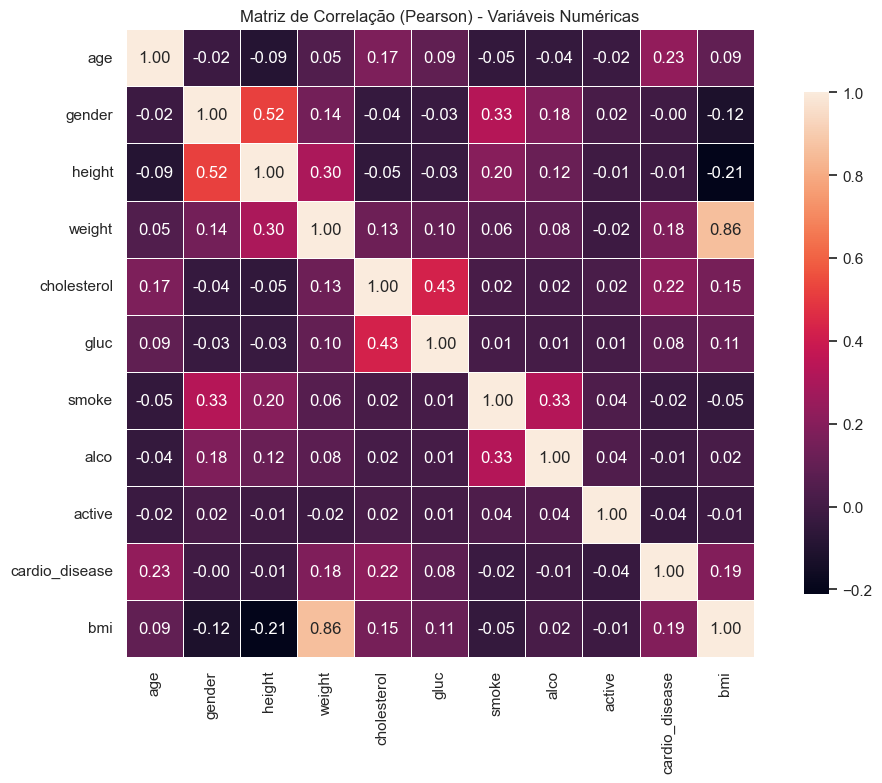

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease,bmi
age,1.000000,-0.017945,-0.088158,0.047258,0.174296,0.091299,-0.049817,-0.044809,-0.022030,0.232952,0.094420
gender,-0.017945,1.000000,0.519585,0.144502,-0.038718,-0.029982,0.331927,0.179126,0.016843,-0.004709,-0.120695
height,-0.088158,0.519585,1.000000,0.301250,-0.052998,-0.028048,0.203878,0.115608,-0.007718,-0.012399,-0.211070
weight,0.047258,0.144502,0.301250,1.000000,0.126919,0.097783,0.059903,0.076853,-0.015625,0.180763,0.861112
cholesterol,0.174296,-0.038718,-0.052998,0.126919,1.000000,0.425912,0.020008,0.015627,0.024753,0.219859,0.154835
gluc,0.091299,-0.029982,-0.028048,0.097783,0.425912,1.000000,0.014352,0.010975,0.009966,0.078544,0.112636
smoke,-0.049817,0.331927,0.203878,0.059903,0.020008,0.014352,1.000000,0.328170,0.036228,-0.022568,-0.045065
alco,-0.044809,0.179126,0.115608,0.076853,0.015627,0.010975,0.328170,1.000000,0.040681,-0.009041,0.016379
active,-0.022030,0.016843,-0.007718,-0.015625,0.024753,0.009966,0.036228,0.040681,1.000000,-0.035741,-0.012841
cardio_disease,0.232952,-0.004709,-0.012399,0.180763,0.219859,0.078544,-0.022568,-0.009041,-0.035741,1.000000,0.188639


In [21]:
# MATRIZ DE CORRELAÇÃO

sns.set_theme(style="whitegrid", context="notebook")

df = df.copy()
df["weight"] = pd.to_numeric(df["weight"].astype(str).str.replace(",", ".", regex=False), errors="coerce")
df["weight"] = df["weight"].fillna(df["weight"].median())

#BMI (IMC)
df["bmi"] = df["weight"] / ((df["height"] / 100) ** 2)

# Seleção apenas de colunas numéricas (robusto e evita erro)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Correlação (Pearson)
corr = df[num_cols].corr(method="pearson")

# Heatmap
plt.figure(figsize=(11, 8))
ax = sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
ax.set_title("Matriz de Correlação (Pearson) - Variáveis Numéricas")
plt.tight_layout()
plt.show()

display(corr)

In [22]:
#PARES MAIS CORRELACIONADOS
def top_correlations(corr_matrix: pd.DataFrame, top_n: int = 10) -> pd.DataFrame:
    corr_abs = corr_matrix.abs()
    upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))  # triângulo superior sem diagonal
    pairs = (
        upper.stack()
             .sort_values(ascending=False)
             .head(top_n)
             .reset_index()
    )
    pairs.columns = ["var_1", "var_2", "abs_corr"]
    return pairs

top_pairs = top_correlations(corr, top_n=12)
display(top_pairs)

,var_1,var_2,abs_corr
0,weight,bmi,0.861112
1,gender,height,0.519585
2,cholesterol,gluc,0.425912
3,gender,smoke,0.331927
4,smoke,alco,0.328170
5,height,weight,0.301250
6,age,cardio_disease,0.232952
7,cholesterol,cardio_disease,0.219859
8,height,bmi,0.211070
9,height,smoke,0.203878


,corr_com_cardio
age,0.232952
cholesterol,0.219859
bmi,0.188639
weight,0.180763
gluc,0.078544
active,-0.035741
smoke,-0.022568
height,-0.012399
alco,-0.009041
gender,-0.004709


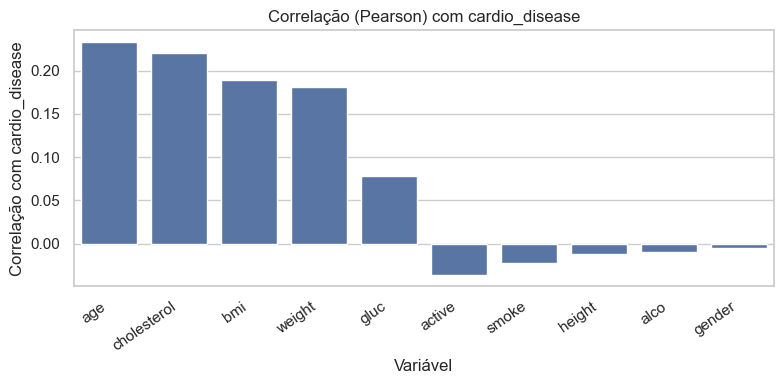

In [23]:
#RELAÇÃO COM O TARGET (DOENÇA CARDIOVASCULAR)
target = "cardio_disease"

corr_target = (
    corr[target]
    .drop(target)
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .rename("corr_com_cardio")
    .to_frame()
)

display(corr_target)

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=corr_target.index, y=corr_target["corr_com_cardio"], errorbar=None)
ax.set_title("Correlação (Pearson) com cardio_disease")
ax.set_xlabel("Variável")
ax.set_ylabel("Correlação com cardio_disease")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

# INSIGHTS #

* Idade: Como esperado, a idade é um dos indicadores mais fortes. Conforme a idade avança, a probabilidade de doenças cardiovasculares aumenta de forma consistente.
* Colesterol e Glicose: Níveis elevados de colesterol e glicose costumam caminhar juntos com o diagnóstico da doença, confirmando a importância desses marcadores.
* Peso, Altura e IMC: Como o IMC já é um resumo do peso e da altura, usar as três variáveis simultaneamente pode gerar redundância no modelo. O ideal é focar no IMC para simplificar a análise sem perder informação.
* Estilo de vida: Curiosamente, variáveis como tabagismo, consumo de álcool e nível de atividade física apresentam uma correlação baixa no dataset. Isso não significa que não sejam importantes, mas indica que o impacto deles pode ser indireto, exigindo uma abordagem mais detalhada na modelagem para verificar esses efeitos.

# 4) Última etapa pré modelo. 

A) Separar a base em treino e teste.

B) Padronização necesserária? Se sim, porque? 

C) Verificar se os dados estão balanceados.

D) Visualização das bases de treino, teste (X E Y) e adequações.

In [28]:
# Feature auxiliar: BMI (recomendado manter ao invés de usar weight+height+BMI juntos)
df["bmi"] = df["weight"] / ((df["height"] / 100) ** 2)

DROP_COLS = []  
use_bmi_only = True

if use_bmi_only:
    features = ["age", "gender", "cholesterol", "gluc", "smoke", "alco", "active", "bmi"]
else:
    features = ["age", "gender", "height", "weight", "cholesterol", "gluc", "smoke", "alco", "active"]

target = "cardio_disease"

X = df[features].drop(columns=DROP_COLS, errors="ignore")
y = df[target].astype(int)

print("Features usadas:", list(X.columns))
print("Shape X:", X.shape, "| Shape y:", y.shape)

#4A) BASE TREINO E TESTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape, y_train.shape)
print("Teste :", X_test.shape,  y_test.shape)

#4B) Dados padronizados. Considerando que irei utilizar a regressão logística, a não padronização pode alterar a comparação dos coeficientes;
# Definir colunas que realmente precisam de escala
continuous_cols = [c for c in ["age", "height", "weight", "bmi"] if c in X_train.columns]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

# Fit no treino
X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols]  = scaler.transform(X_test[continuous_cols])

print("Colunas padronizadas:", continuous_cols)

#4C) Balanceamento. SMOTE somente no treino.
def class_balance(series: pd.Series) -> pd.DataFrame:
    return (
        series.value_counts()
              .rename_axis("classe")
              .reset_index(name="qtd")
              .assign(percent=lambda d: (d["qtd"] / d["qtd"].sum()).round(4))
              .sort_values("classe")
    )

print("Balanceamento original (y total):")
display(class_balance(y))

print("Balanceamento (y_train):")
display(class_balance(y_train))

print("Balanceamento (y_test):")
display(class_balance(y_test))

# Aplicar SMOTE apenas se estiver desbalanceado (regra simples: minoria < 45%)
minority_ratio = y_train.value_counts(normalize=True).min()

if minority_ratio < 0.45:
    smote = SMOTE(random_state=42, k_neighbors=5)
    X_train_final, y_train_final = smote.fit_resample(X_train_scaled, y_train)
    X_test_final, y_test_final = X_test_scaled.copy(), y_test.copy()
    print("SMOTE aplicado no treino ✅")
else:
    X_train_final, y_train_final = X_train_scaled.copy(), y_train.copy()
    X_test_final, y_test_final = X_test_scaled.copy(), y_test.copy()
    print("Base já está bem balanceada — SMOTE não aplicado ✅")

print("\nBalanceamento final (y_train_final):")
display(class_balance(y_train_final))

#4D) Visualizar X e Y e verificar se está ok
print("Shapes finais:")
print("X_train_final:", X_train_final.shape)
print("y_train_final:", y_train_final.shape)
print("X_test_final :", X_test_final.shape)
print("y_test_final :", y_test_final.shape)

print("\nAmostra do X_train_final:")
display(X_train_final.head())

print("\nAmostra do y_train_final:")
display(y_train_final.head())

print("\nAmostra do X_test_final:")
display(X_test_final.head())

print("\nAmostra do y_test_final:")
display(y_test_final.head())

# Checagens de sanidade 
def sanity_check(X_df: pd.DataFrame, name: str):
    n_nan = X_df.isna().sum().sum()
    n_inf = np.isinf(X_df.select_dtypes(include=[np.number]).to_numpy()).sum()
    print(f"{name} -> NaN: {n_nan} | Inf: {n_inf}")

sanity_check(X_train_final, "X_train_final")
sanity_check(X_test_final, "X_test_final")

Features usadas: ['age', 'gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi']
Shape X: (9631, 8) | Shape y: (9631,)
Treino: (7223, 8) (7223,)
Teste : (2408, 8) (2408,)
Colunas padronizadas: ['age', 'bmi']
Balanceamento original (y total):


,classe,qtd,percent
1,0,4735,0.4916
0,1,4896,0.5084


Balanceamento (y_train):


,classe,qtd,percent
1,0,3551,0.4916
0,1,3672,0.5084


Balanceamento (y_test):


...


Amostra do X_test_final:


,age,gender,cholesterol,gluc,smoke,alco,active,bmi
4759,-1.657913,2,1,1,0,0,0,-0.237957
4843,-1.364305,2,1,1,0,0,1,-0.885582
2224,-0.923893,2,1,1,0,0,1,-0.535122
3156,0.690953,1,2,1,0,0,1,2.679265
7828,0.984561,2,1,1,0,0,1,0.202554



Amostra do y_test_final:


4759    0
4843    1
2224    0
3156    1
7828    1
Name: cardio_disease, dtype: int64

X_train_final -> NaN: 0 | Inf: 0
X_test_final -> NaN: 0 | Inf: 0


# 5) Etapas de treinamento do modelo:


In [31]:
#5A) Treinamento do modelo
model = LogisticRegression(
    max_iter=2000,
    solver="liblinear",
    random_state=42
)

model.fit(X_train_final, y_train_final)

print("Modelo treinado ✅")

Modelo treinado ✅


In [32]:
#5B) Intercepts e Coeficiente
# Intercept
intercept = model.intercept_[0]
print(f"Intercept: {intercept:.6f}")

# Coeficientes por feature
coef_df = (
    pd.DataFrame({
        "feature": X_train_final.columns,
        "coef": model.coef_[0]
    })
    .assign(abs_coef=lambda d: d["coef"].abs())
    .sort_values("abs_coef", ascending=False)
    .drop(columns="abs_coef")
    .reset_index(drop=True)
)

display(coef_df)

Intercept: -0.574700


,feature,coef
0,cholesterol,0.600023
1,age,0.406172
2,bmi,0.351574
3,active,-0.209804
4,smoke,-0.169464
5,gluc,-0.134521
6,gender,0.106994
7,alco,0.030476


Accuracy (teste): 0.6350

Classification Report (teste):
              precision    recall  f1-score   support

           0     0.6272    0.6351    0.6311      1184
           1     0.6427    0.6348    0.6387      1224

    accuracy                         0.6350      2408
   macro avg     0.6349    0.6350    0.6349      2408
weighted avg     0.6351    0.6350    0.6350      2408



,Pred 0,Pred 1
Real 0,752,432
Real 1,447,777


ROC AUC (teste): 0.6947


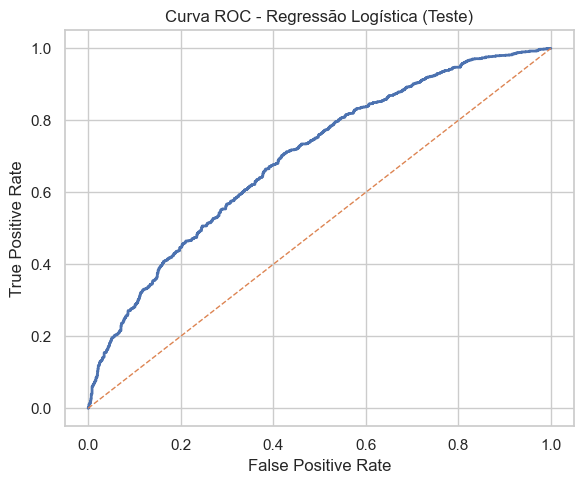

Accuracy (treino): 0.6366
ROC AUC (treino): 0.6917


In [39]:
#5C) METRICAS DO MODELO
# Predições
y_pred = model.predict(X_test_final)
y_proba = model.predict_proba(X_test_final)[:, 1]

# Accuracy
acc = accuracy_score(y_test_final, y_pred)
print(f"Accuracy (teste): {acc:.4f}")

# Classification Report
print("\nClassification Report (teste):")
print(classification_report(y_test_final, y_pred, digits=4))

# Matriz de confusão
cm = confusion_matrix(y_test_final, y_pred)
cm_df = pd.DataFrame(cm, index=["Real 0", "Real 1"], columns=["Pred 0", "Pred 1"])
display(cm_df)

# ROC AUC
auc = roc_auc_score(y_test_final, y_proba)
print(f"ROC AUC (teste): {auc:.4f}")

# Curva ROC
fpr, tpr, _ = roc_curve(y_test_final, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.title("Curva ROC - Regressão Logística (Teste)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.tight_layout()
plt.show()

#VERIFICAR overfitting
y_pred_train = model.predict(X_train_final)
y_proba_train = model.predict_proba(X_train_final)[:, 1]

acc_train = accuracy_score(y_train_final, y_pred_train)
auc_train = roc_auc_score(y_train_final, y_proba_train)

print(f"Accuracy (treino): {acc_train:.4f}")
print(f"ROC AUC (treino): {auc_train:.4f}")

# 5D) Insights e justificativas
O modelo aprendeu alguns padrões e já ajuda a prever. Ele identifica mais ou menos 6 em cada 10 casos corretamente e ainda deixa passar uma parte considerável dos doentes. Então ele serve como primeira versão (baseline), mas precisa de melhorias para ficar mais confiável.
Ajustei o threshold para aumentar o recall da classe 1.

In [46]:
# Probabilidades da classe 1
y_proba = model.predict_proba(X_test_final)[:, 1]

# Grade de thresholds
thresholds = np.arange(0.05, 0.96, 0.01)

rows = []
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    rows.append({
        "threshold": t,
        "precision_1": precision_score(y_test_final, y_pred_t, zero_division=0),
        "recall_1": recall_score(y_test_final, y_pred_t),
        "f1_1": f1_score(y_test_final, y_pred_t),
        "positivos_previstos_%": y_pred_t.mean()
    })

thr_df = pd.DataFrame(rows)

# Escolha por recall-alvo (ajuste aqui)
recall_target = 0.75

candidates = thr_df[thr_df["recall_1"] >= recall_target].copy()

if not candidates.empty:
    # dentre os que atingem o recall alvo, pega o maior F1
    best = candidates.sort_values(["f1_1", "precision_1"], ascending=False).iloc[0]
    strategy = f"Recall alvo >= {recall_target:.2f} (escolhido pelo maior F1 entre candidatos)"
else:
    # se não atingir o recall alvo, pega o maior recall possível com melhor F1
    best = thr_df.sort_values(["recall_1", "f1_1"], ascending=False).iloc[0]
    strategy = f"Não atingiu recall alvo {recall_target:.2f}; escolhido maior recall com desempate em F1"

best_threshold = float(best["threshold"])

print("Estratégia:", strategy)
print("Melhor threshold encontrado:", best_threshold)
display(best.to_frame("valor"))
display(thr_df.sort_values("f1_1", ascending=False).head(10))

#Avaliação final com novo threshold
# Predição com threshold ajustado
y_pred_adj = (y_proba >= best_threshold).astype(int)

print(f"ROC AUC (não muda com threshold): {roc_auc_score(y_test_final, y_proba):.4f}")
print(f"\nThreshold ajustado: {best_threshold:.2f}\n")

print("Classification Report (teste) - threshold ajustado:")
print(classification_report(y_test_final, y_pred_adj, digits=4))

cm = confusion_matrix(y_test_final, y_pred_adj)
cm_df = pd.DataFrame(cm, index=["Real 0", "Real 1"], columns=["Pred 0", "Pred 1"])
display(cm_df)

# Métricas principais em uma linha
prec = precision_score(y_test_final, y_pred_adj, zero_division=0)
rec  = recall_score(y_test_final, y_pred_adj)
f1   = f1_score(y_test_final, y_pred_adj)

print(f"Precision(1): {prec:.4f} | Recall(1): {rec:.4f} | F1(1): {f1:.4f}")
print(f"% de positivos previstos: {y_pred_adj.mean():.3f}")

Estratégia: Recall alvo >= 0.75 (escolhido pelo maior F1 entre candidatos)
Melhor threshold encontrado: 0.30000000000000004


,valor
threshold,0.300000
precision_1,0.547005
recall_1,0.969771
f1_1,0.699470
positivos_previstos_%,0.901163


,threshold,precision_1,recall_1,f1_1,positivos_previstos_%
25,0.30,0.547005,0.969771,0.699470,0.901163
30,0.35,0.564889,0.917484,0.699253,0.825581
26,0.31,0.549533,0.960784,0.699168,0.888704
28,0.33,0.556471,0.937908,0.698509,0.856728
29,0.34,0.560614,0.925654,0.698305,0.839286
31,0.36,0.567692,0.904412,0.697543,0.809801
32,0.37,0.572703,0.891340,0.697347,0.791113
27,0.32,0.551069,0.947712,0.696906,0.874169
24,0.29,0.541610,0.973039,0.695881,0.913206
33,0.38,0.576198,0.874183,0.694580,0.771179


ROC AUC (não muda com threshold): 0.6947

Threshold ajustado: 0.30

Classification Report (teste) - threshold ajustado:
              precision    recall  f1-score   support

           0     0.8445    0.1698    0.2827      1184
           1     0.5470    0.9698    0.6995      1224

    accuracy                         0.5764      2408
   macro avg     0.6958    0.5698    0.4911      2408
weighted avg     0.6933    0.5764    0.4945      2408



,Pred 0,Pred 1
Real 0,201,983
Real 1,37,1187


Precision(1): 0.5470 | Recall(1): 0.9698 | F1(1): 0.6995
% de positivos previstos: 0.901


# NOVOS INSIGHTS #

Após o refinamento, o modelo se consolidou como uma excelente ferramenta de triagem. O grande mérito aqui é a segurança: ele praticamente não deixa casos positivos passarem despercebidos, o que é fundamental em contextos de saúde. Portanto, como priorizamos não deixar "escapar" nenhum paciente doente, o modelo acaba sendo mais conservador e gera um volume maior de falsos positivos. Ou seja, ele encaminha mais pessoas saudáveis para exames complementares.

# 6) Teste do modelo:

In [48]:
# 6A) Aplicando o modelo ao teste ajustado
# Probabilidade da classe 1 no teste
y_proba_test = model.predict_proba(X_test_final)[:, 1]

# Threshold ajustado (do seu resultado)
threshold = 0.30
y_pred_test_adj = (y_proba_test >= threshold).astype(int)

print("Predições realizadas no conjunto de teste ✅")

Predições realizadas no conjunto de teste ✅


In [49]:
# 6B) Avaliação de métricas
# Métricas principais
acc = accuracy_score(y_test_final, y_pred_test_adj)
prec = precision_score(y_test_final, y_pred_test_adj, zero_division=0)
rec = recall_score(y_test_final, y_pred_test_adj)
f1 = f1_score(y_test_final, y_pred_test_adj)

print(f"Threshold: {threshold:.2f}")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision (classe 1): {prec:.4f}")
print(f"Recall (classe 1):    {rec:.4f}")
print(f"F1 (classe 1):        {f1:.4f}")

print("\nClassification Report (teste):")
print(classification_report(y_test_final, y_pred_test_adj, digits=4))

# Matriz de confusão (bem legível)
cm = confusion_matrix(y_test_final, y_pred_test_adj)
cm_df = pd.DataFrame(cm, index=["Real 0", "Real 1"], columns=["Pred 0", "Pred 1"])
display(cm_df)

print(f"% de positivos previstos: {y_pred_test_adj.mean():.3f}")

Threshold: 0.30
Accuracy:  0.5764
Precision (classe 1): 0.5470
Recall (classe 1):    0.9698
F1 (classe 1):        0.6995

Classification Report (teste):
              precision    recall  f1-score   support

           0     0.8445    0.1698    0.2827      1184
           1     0.5470    0.9698    0.6995      1224

    accuracy                         0.5764      2408
   macro avg     0.6958    0.5698    0.4911      2408
weighted avg     0.6933    0.5764    0.4945      2408



,Pred 0,Pred 1
Real 0,201,983
Real 1,37,1187


% de positivos previstos: 0.901


com threshold baixo (0.30), o recall sobe bastante. Minimizando a chance de falsos negativos.

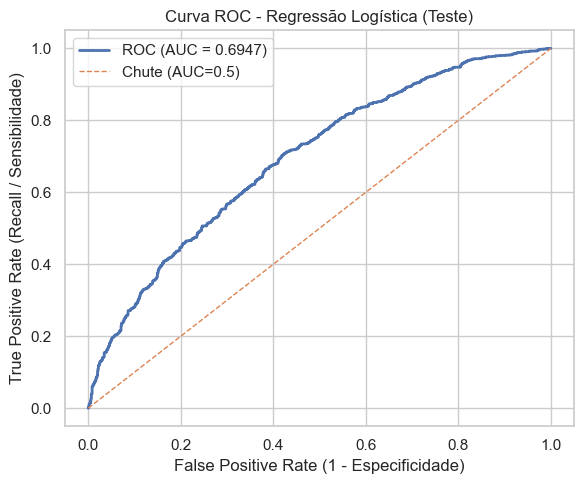

In [50]:
# 6C) AUC ROC
auc = roc_auc_score(y_test_final, y_proba_test)
fpr, tpr, _ = roc_curve(y_test_final, y_proba_test)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Chute (AUC=0.5)")
plt.title("Curva ROC - Regressão Logística (Teste)")
plt.xlabel("False Positive Rate (1 - Especificidade)")
plt.ylabel("True Positive Rate (Recall / Sensibilidade)")
plt.legend()
plt.tight_layout()
plt.show()


# Justificativa #

Visualmente, quanto mais a curva se aproxima do canto superior esquerdo, mais eficiente é o modelo. No nosso caso, o AUC de 0,69 mostra que o modelo já consegue distinguir os grupos melhor do que um palpite aleatório, mas ainda apresenta uma separação moderada.

O ajuste do threshold (como o de 0,30 que usamos) define a estratégia de operação:
Threshold menor: Priorizamos o Recall (pegamos mais doentes), mas aceitamos mais alarmes falsos.
Threshold maior: Reduzimos os falsos positivos, mas corremos o risco de deixar casos reais passarem.


# 7) Explicando:

A) Regressão logística é um modelo que pega as variáveis de entrada e calcula a probabilidade de um evento acontecer — por exemplo, a probabilidade de uma pessoa ter doença cardíaca. No fim, ela não “chuta” direto 0 ou 1: ela estima uma chance (tipo 0,73) e depois você decide a partir de qual ponto vira “sim”.

B) A regressão logistica é um modelo de classificação porque o objetivo final é colocar o exemplo em uma classe de sim e não (ex.: doente vs não-doente). Ela faz isso transformando a combinação das variáveis em uma probabilidade entre 0 e 1 (usando a função sigmoide) e, com um threshold, converte isso em rótulo: se passou do limite, classe 1; se não, classe 0.

C) Os pontos em comum da regressão logistica e da regressão linear. Elas são bem parecidas na “estrutura”: ambas fazem uma combinação linear das variáveis, mas na regressão linear, esse valor vira diretamente uma previsão numérica e na regreção logística, uma probabilidade de 0 a 1. O que muda é a interpretação do resultado e sua otimização.



In [ ]:
# seu código aqui